In [1]:
! pip install chembl_webresource_client rdkit pandas numpy scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

EDA_Analysis= pd.read_csv('/content/EGFR_final.csv', sep=',')
EDA_Analysis

,molecule_chembl_id,canonical_smiles,standard_value,standard_units,pchembl_value,activity_comment,assay_type,target_chembl_id,type,pIC50,Bioactivity class,Mw,LogP,NumHDonors,NumHAcceptors
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0,nM,7.39,NaN,B,CHEMBL203,IC50,-7.387216,Active,383.814,4.45034,3.0,4.0
1,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,300.0,nM,6.52,NaN,F,CHEMBL203,IC50,-6.522879,Active,383.814,4.45034,3.0,4.0
2,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.0,nM,6.77,NaN,B,CHEMBL203,IC50,-6.769551,Active,482.903,3.61432,3.0,6.0
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,40.0,nM,7.40,NaN,F,CHEMBL203,IC50,-7.397940,Active,482.903,3.61432,3.0,6.0
4,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,440.0,nM,6.36,NaN,F,CHEMBL203,IC50,-6.356547,Active,482.903,3.61432,3.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12113,CHEMBL4546553,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)...,550.0,nM,6.26,742526.0,B,CHEMBL203,IC50,-6.259637,Active,575.087,6.15538,2.0,9.0
12114,CHEMBL4576802,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)...,550.0,nM,6.26,742527.0,B,CHEMBL203,IC50,-6.259637,Active,488.997,5.99098,2.0,7.0
12115,CHEMBL4576802,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)...,550.0,nM,6.26,742528.0,B,CHEMBL203,IC50,-6.259637,Active,488.997,5.99098,2.0,7.0
12116,CHEMBL5949708,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)...,50.0,nM,7.30,742530.0,B,CHEMBL203,IC50,-7.301030,Active,488.997,6.13348,2.0,7.0


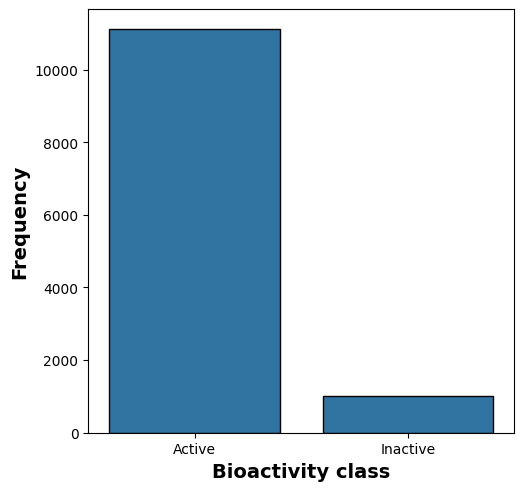

<Figure size 640x480 with 0 Axes>

In [3]:
plt.figure(figsize=(5.5, 5.5))
sns.countplot(x='Bioactivity class', data=EDA_Analysis, edgecolor='black')
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.show()
plt.savefig('Bioactivity_class.png')

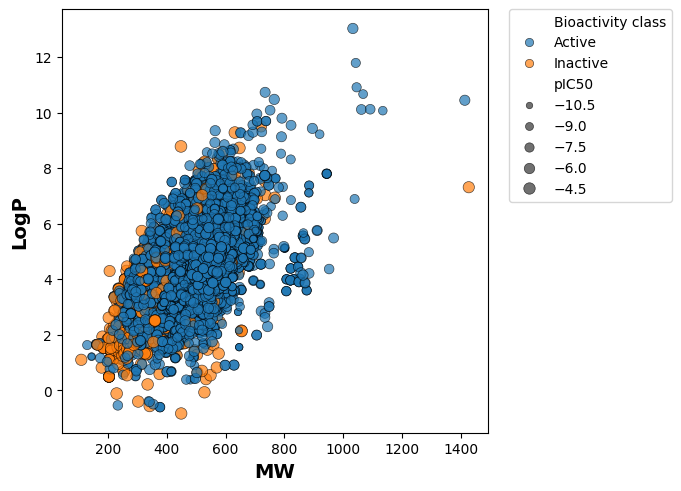

<Figure size 640x480 with 0 Axes>

In [4]:
plt.figure(figsize=(5.5, 5.5))
sns.scatterplot(x='Mw', y='LogP', data=EDA_Analysis, hue='Bioactivity class', size='pIC50', edgecolor='black', alpha=0.7)
plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.show()
plt.savefig('MW_vs_LogP.png')

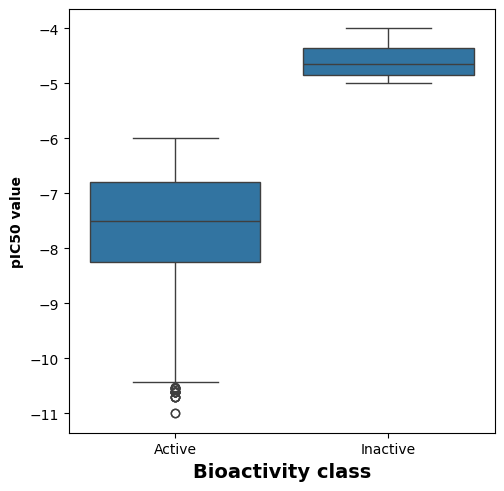

<Figure size 640x480 with 0 Axes>

In [5]:
plt.figure(figsize=(5.5, 5.5))
sns.boxplot(x='Bioactivity class', y='pIC50', data=EDA_Analysis)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=10, fontweight='bold')
plt.show()
plt.savefig('pIC50.png')

In [7]:
def mannwhitney(descriptor, verbose=False):
   from numpy.random import seed
   from numpy.random import randn
   from scipy.stats import mannwhitneyu

   seed(1)

In [11]:
def mannwhitney(descriptor, verbose=False):
    from numpy.random import seed
    from numpy.random import randn
    from scipy.stats import mannwhitneyu
    seed(1)

    selection = [descriptor, 'Bioactivity class']
    df = EDA_Analysis[selection]
    active = df[df['Bioactivity class'] == 'active']
    active = active[descriptor]
    selection = [descriptor, 'Bioactivity class']
    df = EDA_Analysis[selection]
    inactive = df[df['Bioactivity class'] == 'inactive']
    inactive = inactive[descriptor]

    stat, p = mannwhitneyu(active, inactive)
    alpha = 0.05
    if p > alpha:
        interpretation = 'Same distribution (fail to reject H0)'
    else:
        interpretation = 'Different distribution (reject H0)'

    results = pd.DataFrame({'Descriptor':descriptor, 'Statistics':stat, 'p':p, 'alpha':alpha, 'Interpretation':interpretation}, index=[0])
    filename = 'mannwhitneyu_' + descriptor + '.csv'
    results.to_csv()
    return results

In [12]:
mannwhitney('pIC50')

/tmp/ipykernel_2051/25718060.py:16: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(active, inactive)


,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,NaN,NaN,0.05,Different distribution (reject H0)


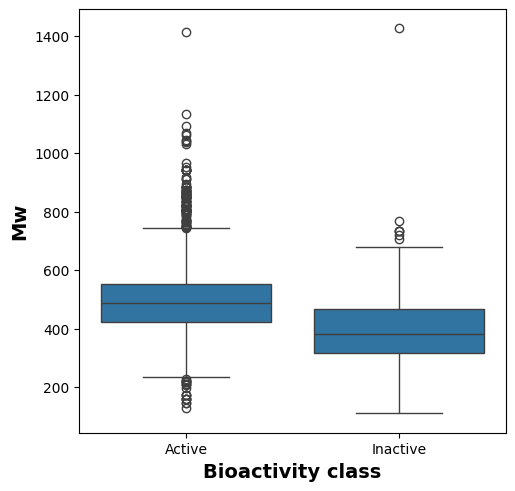

<Figure size 640x480 with 0 Axes>

In [13]:
plt.figure(figsize=(5.5, 5.5))
sns.boxplot(x='Bioactivity class', y='Mw', data=EDA_Analysis)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Mw', fontsize=14, fontweight='bold')
plt.show()
plt.savefig('Mw.png')
#

In [14]:
mannwhitney('Mw')
#

/tmp/ipykernel_2051/25718060.py:16: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(active, inactive)


,Descriptor,Statistics,p,alpha,Interpretation
0,Mw,NaN,NaN,0.05,Different distribution (reject H0)


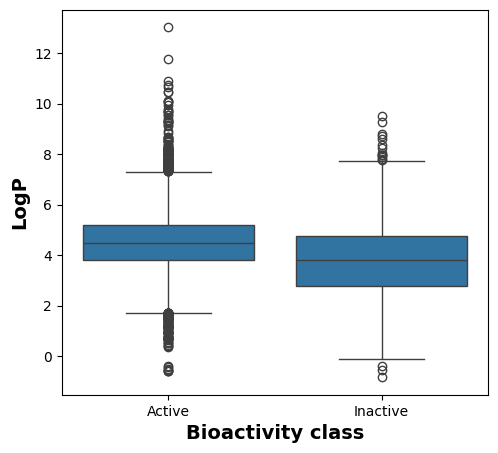

<Figure size 640x480 with 0 Axes>

In [15]:
plt.figure(figsize=(5.5, 5.))
sns.boxplot(x='Bioactivity class', y='LogP', data=EDA_Analysis)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.show()
plt.savefig('LogP.png')
#

In [16]:
mannwhitney('LogP')

/tmp/ipykernel_2051/25718060.py:16: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(active, inactive)


,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,NaN,NaN,0.05,Different distribution (reject H0)


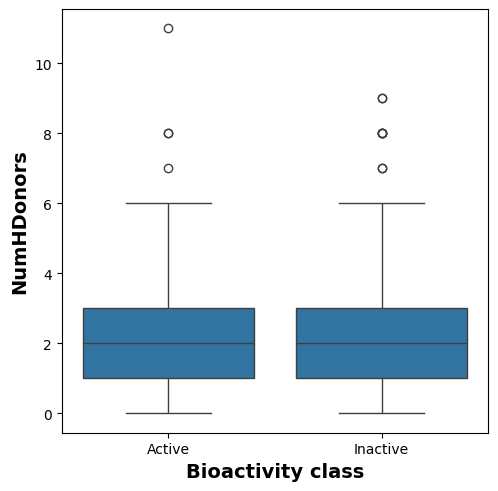

<Figure size 640x480 with 0 Axes>

In [17]:
plt.figure(figsize=(5.5,5.5))
sns.boxplot(x='Bioactivity class', y='NumHDonors', data=EDA_Analysis)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')
plt.show()
plt.savefig('NumHDonors.png')
#

In [18]:
mannwhitney('NumHDonors')
#

/tmp/ipykernel_2051/25718060.py:16: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(active, inactive)


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,NaN,NaN,0.05,Different distribution (reject H0)


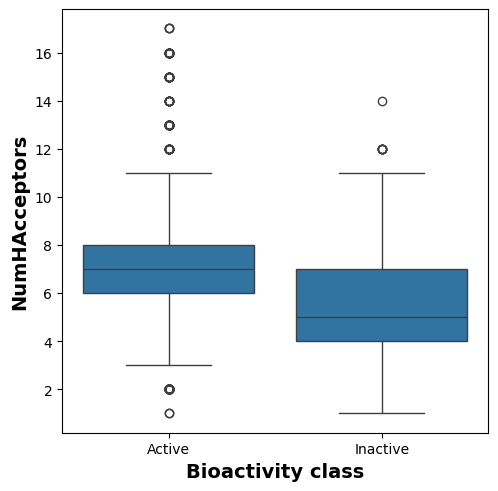

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure(figsize=(5.5,5.5))
sns.boxplot(x='Bioactivity class', y='NumHAcceptors', data=EDA_Analysis)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')
plt.show()
plt.savefig('NumHAcceptors.png')
#

In [20]:
mannwhitney('NumHAcceptors')
#

/tmp/ipykernel_2051/25718060.py:16: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(active, inactive)


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,NaN,NaN,0.05,Different distribution (reject H0)
